# Concat Ensemble Analysis

Ноутбук берет 12 равномерно выбранных кейсов из `valid`, строит для них conditioning через concatenation и затем генерирует ансамбль для каждого кейса.

In [ ]:
import glob
import json
import os
import platform

import matplotlib.pyplot as plt
import numpy as np
import torch
from diffusers.models.unets.unet_2d import UNet2DModel
from diffusers.training_utils import EMAModel
from functools import partial

from concat.sampler import Sampler
from utils import (
    NpyImageDataset,
    channel_normalize,
    generate_satellite_track_mask,
    get_device,
    make_ensemble_case_plot,
    make_plot,
    make_scalar_plot_grid,
)

if platform.system() == 'Darwin':
    REPO_DIR = '/Users/amir/sciml/diffusion_data_assimilation'
    DATA_ROOT = '/Users/amir/sciml/sea_ice_data'
else:
    REPO_DIR = '/home'
    DATA_ROOT = '/mnt/sciml/a.sadreev/sea_ice_data'

os.chdir(REPO_DIR)

CONCAT_RUN_DIR = None
CHECKPOINT_DIR = os.path.join(REPO_DIR, 'checkpoints')
CHECKPOINT_NAME = 'ema_best_model.pth'

N_CASES = 12
ENSEMBLE_SIZE = 10
NUM_TIMESTEPS = 10
METHOD = 'dopri5'
N_TRACKS_RANGE = (7, 7)
BASE_SEED = 1234
IMAGE_SIZE = (320, 256)

DEVICE = get_device()

with open(os.path.join(DATA_ROOT, 'train', 'stats.json')) as f:
    stats = json.load(f)
CHANNEL_MEAN = tuple(stats['mean'])
CHANNEL_STD = tuple(stats['std'])

print('repo_dir      =', REPO_DIR)
print('data_root     =', DATA_ROOT)
print('device        =', DEVICE)
print('n_cases       =', N_CASES)
print('ensemble_size =', ENSEMBLE_SIZE)
print('num_timesteps =', NUM_TIMESTEPS)
print('method        =', METHOD)
print('n_tracks_range=', N_TRACKS_RANGE)
print('channel_mean  =', CHANNEL_MEAN)
print('channel_std   =', CHANNEL_STD)

repo_dir      = /home
data_root     = /mnt/sciml/a.sadreev/sea_ice_data
device        = cuda
n_cases       = 12
ensemble_size = 50
num_timesteps = 10
method        = dopri5
n_tracks_range= (6, 6)
channel_mean  = (0.1158, 0.1153)
channel_std   = (0.3008, 0.3501)


In [8]:
if CONCAT_RUN_DIR is None:
    candidates = sorted(glob.glob(os.path.join(CHECKPOINT_DIR, '**', CHECKPOINT_NAME), recursive=True))
    assert candidates, f'No {CHECKPOINT_NAME} found under {CHECKPOINT_DIR}'
    CONCAT_RUN_DIR = os.path.dirname(candidates[-1])

print('concat_run_dir =', CONCAT_RUN_DIR)

model = UNet2DModel(
    sample_size=IMAGE_SIZE,
    in_channels=7,
    out_channels=2,
    layers_per_block=2,
    block_out_channels=(64, 128, 256, 512, 512),
    down_block_types=(
        'DownBlock2D', 'DownBlock2D', 'DownBlock2D',
        'AttnDownBlock2D', 'DownBlock2D',
    ),
    up_block_types=(
        'UpBlock2D', 'AttnUpBlock2D', 'UpBlock2D',
        'UpBlock2D', 'UpBlock2D',
    ),
)

checkpoint_path = os.path.join(CONCAT_RUN_DIR, CHECKPOINT_NAME)
ema = EMAModel(model.parameters(), decay=0.999)
try:
    ema_state = torch.load(checkpoint_path, map_location='cpu', weights_only=True)
except TypeError:
    ema_state = torch.load(checkpoint_path, map_location='cpu')
ema.load_state_dict(ema_state)
ema.copy_to(model.parameters())
model.eval().to(DEVICE)

sampler = Sampler(model)
print('model loaded from', checkpoint_path)

concat_run_dir = /home/checkpoints/run_20260305_230016
model loaded from /home/checkpoints/run_20260305_230016/ema_best_model.pth


indices          = [   0  796 1592 2388 3185 3981 4777 5573 6370 7166 7962 8759]
clean_images     = (12, 2, 320, 256)
mask_batched     = (12, 1, 320, 256)
observed         = (12, 2, 320, 256)
mask coverage    = 0.01563415676355362


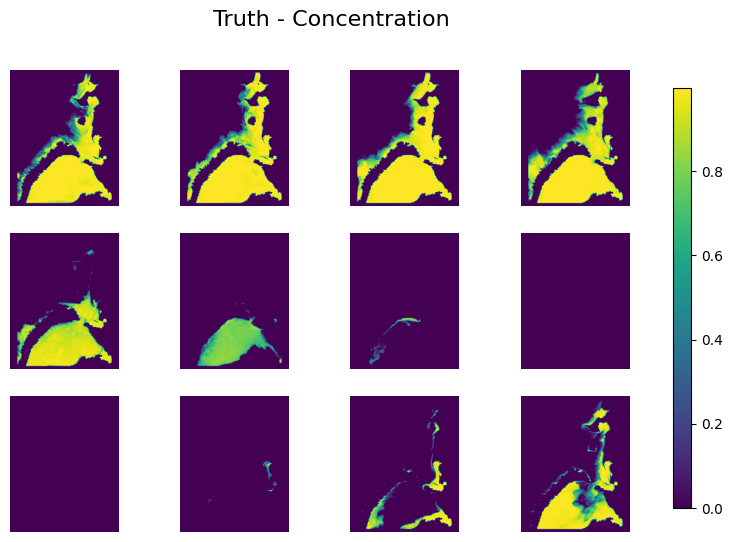

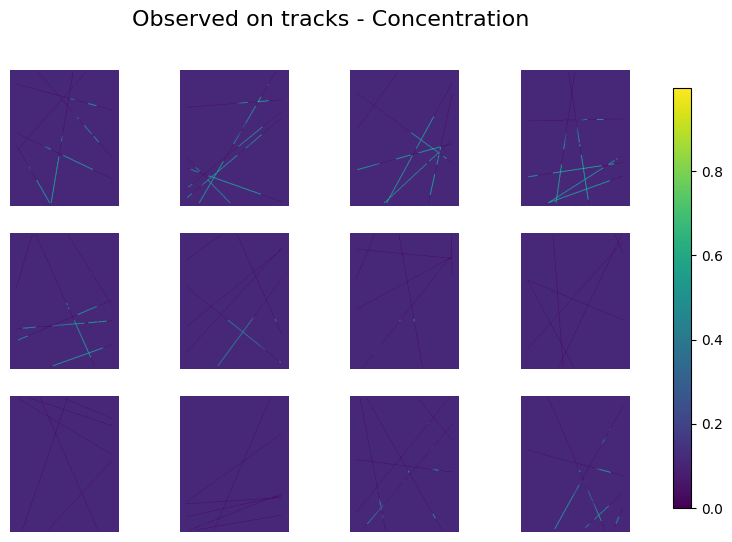

In [9]:
transform = partial(channel_normalize, channel_mean=CHANNEL_MEAN, channel_std=CHANNEL_STD)

val_dataset = NpyImageDataset(
    folder=os.path.join(DATA_ROOT, 'valid'),
    transform=transform,
    preload=False,
    mmap_mode='r',
)
indices = np.linspace(0, len(val_dataset) - 1, N_CASES, dtype=int)
clean_images = torch.stack([val_dataset[i] for i in indices]).to(DEVICE)

valid_mask = np.load(os.path.join(DATA_ROOT, 'mask_padding.npy')).astype(np.float32)
np.random.seed(BASE_SEED)
mask_np = generate_satellite_track_mask(
    image_size=IMAGE_SIZE,
    batch_size=N_CASES,
    valid_mask=valid_mask,
    n_tracks_range=N_TRACKS_RANGE,
)
mask_batched = torch.from_numpy(mask_np).unsqueeze(1).to(DEVICE)
observed = clean_images * mask_batched

print('indices          =', indices)
print('clean_images     =', tuple(clean_images.shape))
print('mask_batched     =', tuple(mask_batched.shape))
print('observed         =', tuple(observed.shape))
print('mask coverage    =', float(mask_batched.mean().item()))

make_plot(clean_images.detach().cpu(), CHANNEL_MEAN, CHANNEL_STD, N_CASES, title='Truth - Concentration')
make_plot(observed.detach().cpu(), CHANNEL_MEAN, CHANNEL_STD, N_CASES, title='Observed on tracks - Concentration')

In [10]:
ensemble_members = []
for member_idx in range(ENSEMBLE_SIZE):
    seed = BASE_SEED + member_idx
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

    predictions = sampler.sample_conditioned(
        mask=mask_batched,
        observed=observed,
        size=IMAGE_SIZE,
        num_timesteps=NUM_TIMESTEPS,
        device=DEVICE,
        method=METHOD,
    )
    ensemble_members.append(predictions.detach().cpu())

ensemble = torch.stack(ensemble_members, dim=0)
ensemble_mean = ensemble.mean(dim=0)
ensemble_std = ensemble.std(dim=0, unbiased=False)

truth_cpu = clean_images.detach().cpu()
mask_cpu = mask_batched.detach().cpu()
mask_2ch = mask_cpu.expand(-1, truth_cpu.shape[1], -1, -1)

case_rmse = torch.sqrt(((ensemble_mean - truth_cpu) ** 2).mean(dim=(1, 2, 3)))
masked_case_rmse = torch.sqrt(
    (((ensemble_mean - truth_cpu) ** 2 * mask_2ch).sum(dim=(1, 2, 3)) / mask_2ch.sum(dim=(1, 2, 3)).clamp(min=1.0))
)
member_rmse = torch.sqrt(((ensemble - truth_cpu.unsqueeze(0)) ** 2).mean(dim=(2, 3, 4)))

summary = {
    'ensemble_size': ENSEMBLE_SIZE,
    'n_cases': N_CASES,
    'rmse_mean': float(case_rmse.mean().item()),
    'rmse_std': float(case_rmse.std(unbiased=False).item()),
    'masked_rmse_mean': float(masked_case_rmse.mean().item()),
    'masked_rmse_std': float(masked_case_rmse.std(unbiased=False).item()),
    'member_rmse_mean': float(member_rmse.mean().item()),
    'member_rmse_std': float(member_rmse.std(unbiased=False).item()),
    'ensemble_spread_mean': float(ensemble_std.mean().item()),
    'ensemble_spread_std': float(ensemble_std.std(unbiased=False).item()),
}
print(json.dumps(summary, indent=2))
print('case_rmse        =', case_rmse.tolist())
print('masked_case_rmse =', masked_case_rmse.tolist())

{
  "ensemble_size": 50,
  "n_cases": 12,
  "rmse_mean": 0.2875223457813263,
  "rmse_std": 0.19858045876026154,
  "masked_rmse_mean": 0.1021779254078865,
  "masked_rmse_std": 0.07060389220714569,
  "member_rmse_mean": 0.3650020956993103,
  "member_rmse_std": 0.23426920175552368,
  "ensemble_spread_mean": 0.10985516756772995,
  "ensemble_spread_std": 0.23224370181560516
}
case_rmse        = [0.19811272621154785, 0.32213544845581055, 0.3423205018043518, 0.47212550044059753, 0.48802700638771057, 0.7291895747184753, 0.33615991473197937, 0.013585488311946392, 0.04240218177437782, 0.08539468050003052, 0.18371394276618958, 0.23710107803344727]
masked_case_rmse = [0.06399737298488617, 0.12975060939788818, 0.14069269597530365, 0.16426345705986023, 0.2427198886871338, 0.18548911809921265, 0.10162524878978729, 0.013110273517668247, 0.01270255632698536, 0.015969576314091682, 0.05531409755349159, 0.10050022602081299]


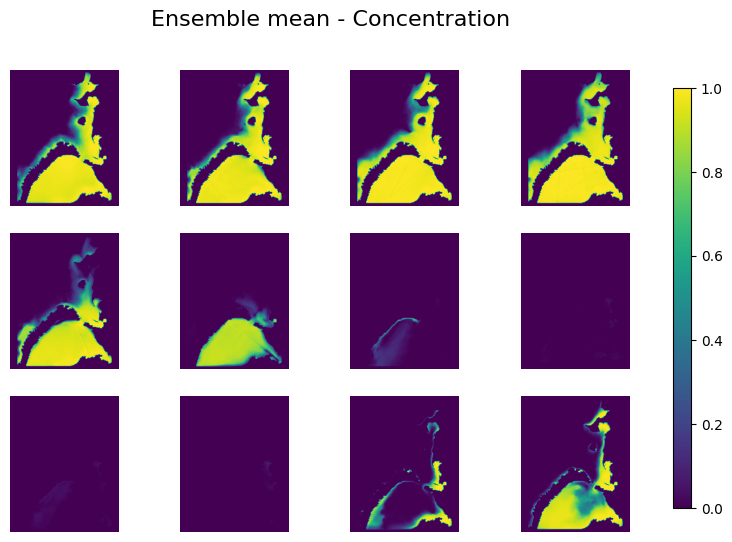

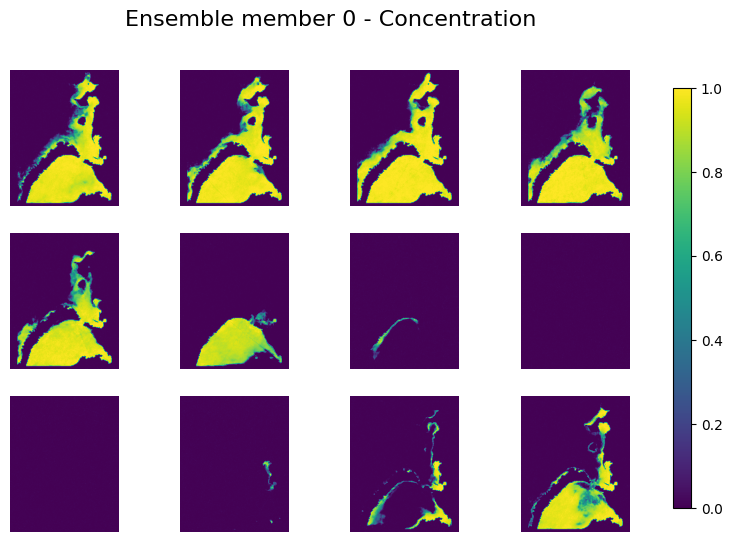

/tmp/ipykernel_1149891/3801870769.py:17: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


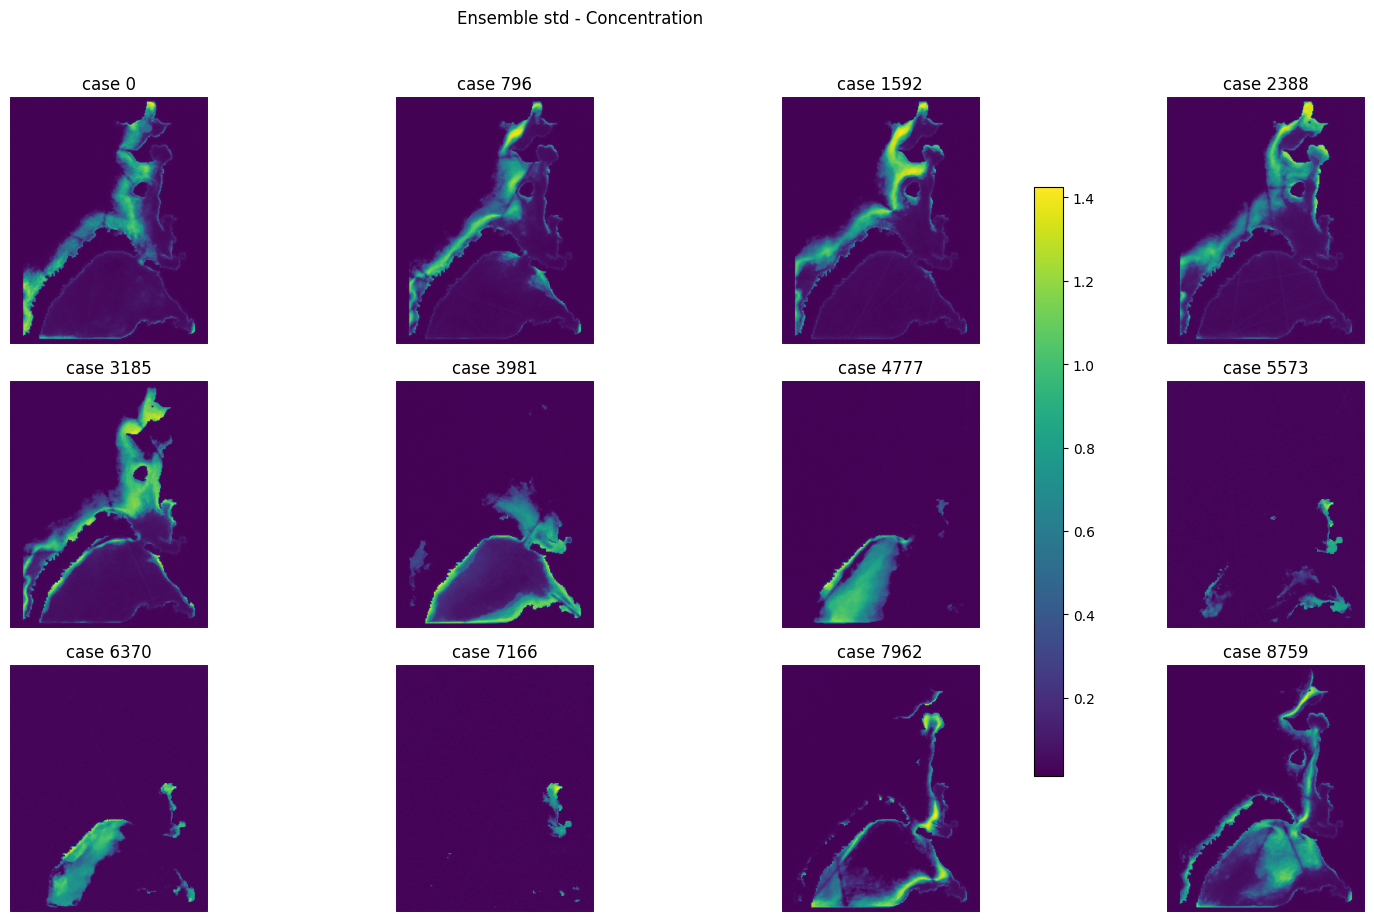

In [12]:
make_plot(ensemble_mean, CHANNEL_MEAN, CHANNEL_STD, N_CASES, title='Ensemble mean - Concentration')
make_plot(ensemble[0], CHANNEL_MEAN, CHANNEL_STD, N_CASES, title='Ensemble member 0 - Concentration')

make_scalar_plot_grid(
    ensemble_std[:, 0],
    N_CASES,
    title='Ensemble std - Concentration',
    cmap='magma',
    case_labels=[f'case {int(i)}' for i in indices],
)

make_ensemble_case_plot(
    ensemble,
    CHANNEL_MEAN,
    CHANNEL_STD,
    case_indices=indices,
    title_prefix='Case',
)